In [7]:
#!pip install kaggle
#!mkdir -p ~/.kaggle
#!cp kaggle.json ~/.kaggle/
#!chmod 600 ~/.kaggle/kaggle.json

Importing




In [8]:

!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [9]:
# extracting the compessed Dataset

from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()


**Importing the Dependencies**

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [11]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_2791.jpg', 'with_mask_2866.jpg', 'with_mask_1709.jpg', 'with_mask_2039.jpg', 'with_mask_2793.jpg']
['with_mask_1154.jpg', 'with_mask_1122.jpg', 'with_mask_850.jpg', 'with_mask_442.jpg', 'with_mask_1927.jpg']


In [12]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_3764.jpg', 'without_mask_3083.jpg', 'without_mask_3118.jpg', 'without_mask_1269.jpg', 'without_mask_2516.jpg']
['without_mask_2698.jpg', 'without_mask_2954.jpg', 'without_mask_2236.jpg', 'without_mask_2375.jpg', 'without_mask_1967.jpg']


**Creating Labels**

with mask  -->  1

without mask  -->  0

In [13]:
# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [14]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [15]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


**Displaying the Images**

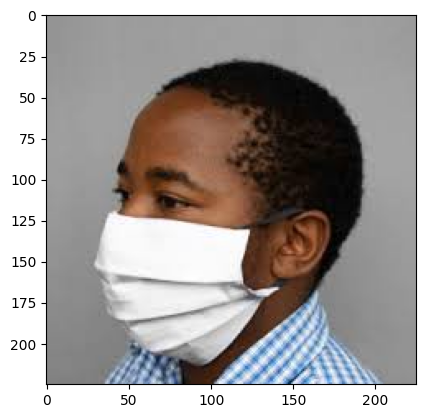

In [16]:
img = mpimg.imread('/content/data/with_mask/with_mask_2866.jpg')
imgplot = plt.imshow(img)
plt.show()

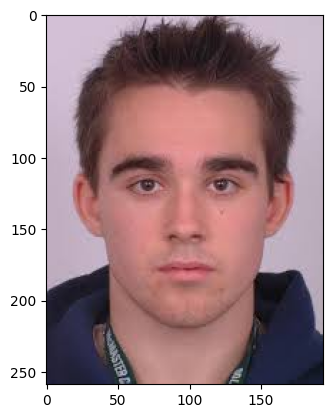

In [17]:
img = mpimg.imread('/content/data/without_mask/without_mask_2375.jpg')
imgplot = plt.imshow(img)
plt.show()

**Image Processing**

1. Resize the Images

2. Convert the images to numpy arrays

#Convert images to numpy arrays+

In [18]:
with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file) # we take image
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [19]:
without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

In [20]:
data[0].shape

(128, 128, 3)

In [21]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [22]:
type(X)

numpy.ndarray

In [23]:
type(Y)

numpy.ndarray

##Train Test Split

In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [25]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


##Scaling the data

In [26]:
X_train_scaled = X_train/255

X_test_scaled = X_test/255

In [27]:
X_train_scaled[0]

array([[[0.15294118, 0.0627451 , 0.10196078],
        [0.2       , 0.10196078, 0.13333333],
        [0.21960784, 0.10980392, 0.13333333],
        ...,
        [0.14509804, 0.06666667, 0.13333333],
        [0.12941176, 0.06666667, 0.1254902 ],
        [0.11372549, 0.05882353, 0.10980392]],

       [[0.17647059, 0.0745098 , 0.10196078],
        [0.16078431, 0.05882353, 0.08235294],
        [0.14901961, 0.02745098, 0.04705882],
        ...,
        [0.17254902, 0.09803922, 0.16470588],
        [0.16078431, 0.09411765, 0.15294118],
        [0.1254902 , 0.0745098 , 0.12156863]],

       [[0.25882353, 0.14117647, 0.15294118],
        [0.19607843, 0.0745098 , 0.08235294],
        [0.17647059, 0.03529412, 0.03921569],
        ...,
        [0.22352941, 0.15294118, 0.21960784],
        [0.21176471, 0.14901961, 0.20784314],
        [0.17647059, 0.11764706, 0.16862745]],

       ...,

       [[0.69019608, 0.63529412, 0.69803922],
        [0.69019608, 0.63529412, 0.69803922],
        [0.69019608, 0

#Building a Convolutional Neural Networks

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class CNNModel(nn.Module):
    def __init__(self, num_classes=2, input_size=(3, 128, 128)):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3)


        with torch.no_grad():
            x = torch.zeros(1, *input_size)
            x = self.pool(F.relu(self.conv1(x)))
            x = self.pool(F.relu(self.conv2(x)))
            fc_input_size = x.numel()

        self.fc1 = nn.Linear(fc_input_size, 128)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.reshape(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.sigmoid(self.fc3(x))
        return x

In [33]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split


X = torch.tensor(X_train_scaled, dtype=torch.float32)
y = torch.tensor(Y_train, dtype=torch.long)

dataset = TensorDataset(X, y)
model = CNNModel()

val_size = int(0.1 * len(dataset))
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

epochs = 5

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()


        xb = xb.permute(0, 3, 1, 2)

        outputs = model(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in val_loader:

            xb = xb.permute(0, 3, 1, 2)

            outputs = model(xb)
            loss = criterion(outputs, yb)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += yb.size(0)
            correct += (predicted == yb).sum().item()

    val_acc = correct / total

    print(f"Epoch {epoch+1}/{epochs}, "
          f"Train Loss: {train_loss:.4f}, "
          f"Val Loss: {val_loss:.4f}, "
          f"Val Acc: {val_acc:.4f}")

Epoch 1/5, Train Loss: 83.2032, Val Loss: 8.3187, Val Acc: 0.8709
Epoch 2/5, Train Loss: 74.4639, Val Loss: 8.4310, Val Acc: 0.8709
Epoch 3/5, Train Loss: 71.4531, Val Loss: 8.0179, Val Acc: 0.8924


In [ ]:
torch.save(model.state_dict(), 'cnn_model.pth')

In [ ]:
torch.save(model, 'cnn_model_full.pth')

**Predictive System**

In [ ]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

# model = CNNModel(num_classes=2)
# model.load_state_dict(torch.load('cnn_model.pth'))
# model.eval()

input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)
if input_image is None:
    raise ValueError("Image not found. Check the path.")


input_image_rgb = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)
plt.imshow(input_image_rgb)
plt.axis('off')
plt.show()

input_image_resized = cv2.resize(input_image, (128, 128))
input_image_scaled = input_image_resized / 255.0
input_image_chw = np.transpose(input_image_scaled, (2, 0, 1))
input_image_tensor = torch.tensor(input_image_chw, dtype=torch.float32).unsqueeze(0)

model.eval()
with torch.no_grad():
    output = model(input_image_tensor)
    input_pred_label = torch.argmax(output, dim=1).item()

if input_pred_label == 1:
    print('The person in the image is wearing a mask')
else:
    print('The person in the image is not wearing a mask')

In [ ]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')